# Fraud Detection — Exploratory Data Analysis

This notebook explores the raw credit card transaction dataset before any modelling.
It covers:
1. Dataset overview & data quality
2. Class imbalance
3. Transaction amount & time distributions
4. Feature distributions (fraud vs. legitimate)
5. Correlation heatmap
6. Feature engineering preview (`hour` feature)
7. Key takeaways for modelling

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
Features `V1–V28` are PCA-transformed for confidentiality. `Time`, `Amount`, and `Class` are the original columns.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/raw/creditcard.csv'

## 1. Dataset Overview

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values ✅')
print()
print('--- Duplicate Rows ---')
dupes = df.duplicated().sum()
print(f'{dupes} duplicate rows found' if dupes else 'No duplicates ✅')

--- Data Types ---
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

--- Missing Values ---
No missing values ✅

--- Duplicate Rows ---
1081 duplicate rows found


In [7]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.000000,0.000000,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.000000,0.000000,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.000000,-0.000000,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.000000,0.000000,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.000000,0.000000,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.000000,0.000000,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.000000,-0.000000,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.000000,0.000000,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.000000,-0.000000,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 2. Class Imbalance

This is the most important characteristic of the dataset. Fraud cases are extremely rare.

In [9]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('Class distribution:')
print(f'  Legitimate (0): {class_counts[0]:,}  ({class_pct[0]:.4f}%)')
print(f'  Fraud      (1): {class_counts[1]:,}  ({class_pct[1]:.4f}%)')
print(f'  Imbalance ratio: {class_counts[0] / class_counts[1]:.0f}:1')

Class distribution:
  Legitimate (0): 284,315  (99.8273%)
  Fraud      (1): 492  (0.1727%)
  Imbalance ratio: 578:1


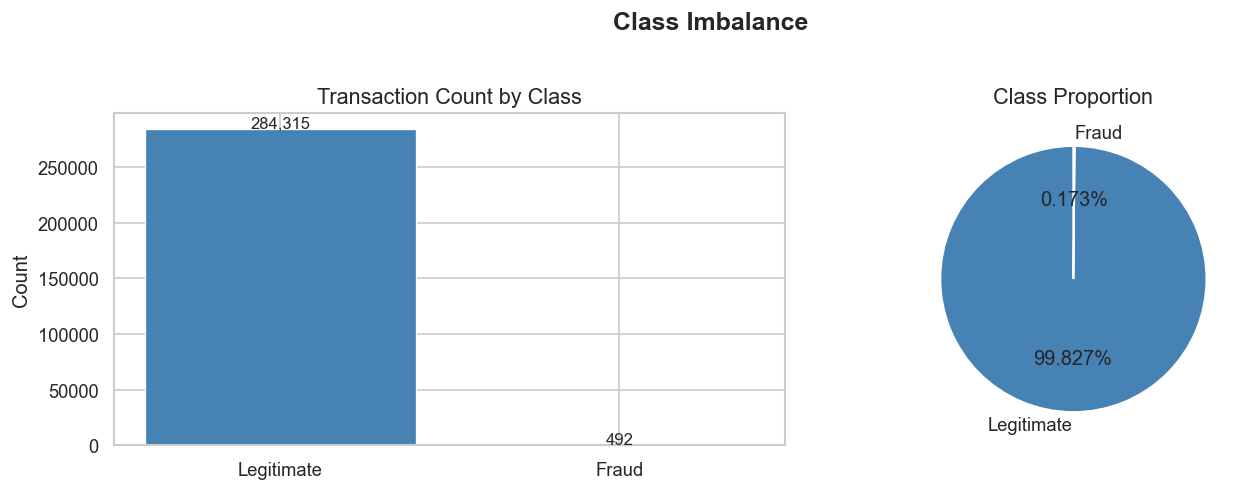


⚠️  Takeaway: ~0.17% fraud rate. Accuracy is a misleading metric here.
   Use Precision-Recall AUC and F1-score instead.
   Model training uses scale_pos_weight to compensate for imbalance.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Transaction Count by Class', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Proportion', fontsize=13)

plt.suptitle('Class Imbalance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n⚠️  Takeaway: ~0.17% fraud rate. Accuracy is a misleading metric here.')
print('   Use Precision-Recall AUC and F1-score instead.')
print('   Model training uses scale_pos_weight to compensate for imbalance.')

## 3. Transaction Amount & Time

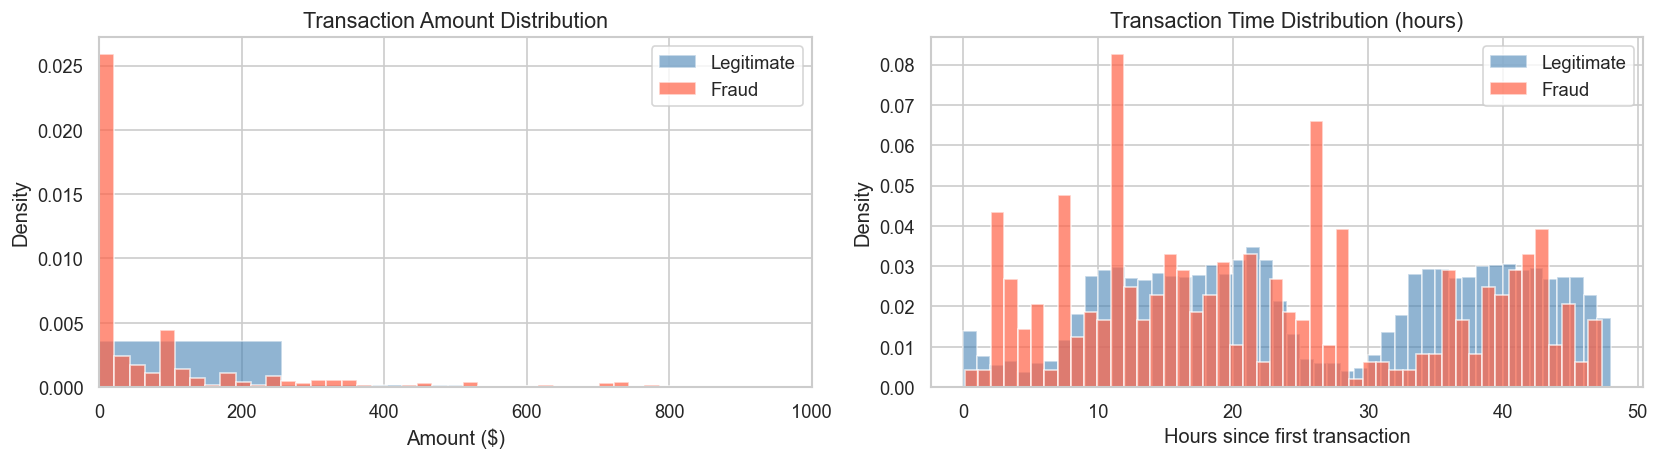

In [14]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount distribution
axes[0].hist(legit['Amount'], bins=100, alpha=0.6, color='steelblue',
             label='Legitimate', density=True)
axes[0].hist(fraud['Amount'], bins=100, alpha=0.7, color='tomato',
             label='Fraud', density=True)
axes[0].set_xlim(0, 1000)
axes[0].set_title('Transaction Amount Distribution', fontsize=13)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Time distribution
axes[1].hist(legit['Time'] / 3600, bins=48, alpha=0.6, color='steelblue',
             label='Legitimate', density=True)
axes[1].hist(fraud['Time'] / 3600, bins=48, alpha=0.7, color='tomato',
             label='Fraud', density=True)
axes[1].set_title('Transaction Time Distribution (hours)', fontsize=13)
axes[1].set_xlabel('Hours since first transaction')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
print('Amount statistics:')
comparison = pd.DataFrame({
    'Legitimate': legit['Amount'].describe(),
    'Fraud': fraud['Amount'].describe()
})
print(comparison.round(2))
print()
print('⚠️  Takeaway: Fraud transactions tend to be smaller amounts — harder to detect.')

Amount statistics:
       Legitimate    Fraud
count   284315.00   492.00
mean        88.29   122.21
std        250.11   256.68
min          0.00     0.00
25%          5.65     1.00
50%         22.00     9.25
75%         77.05   105.89
max      25691.16  2125.87

⚠️  Takeaway: Fraud transactions tend to be smaller amounts — harder to detect.


## 4. Feature Engineering Preview — `hour` Feature

The pipeline converts `Time` (seconds) into an `hour` feature (0–23) to capture daily patterns.

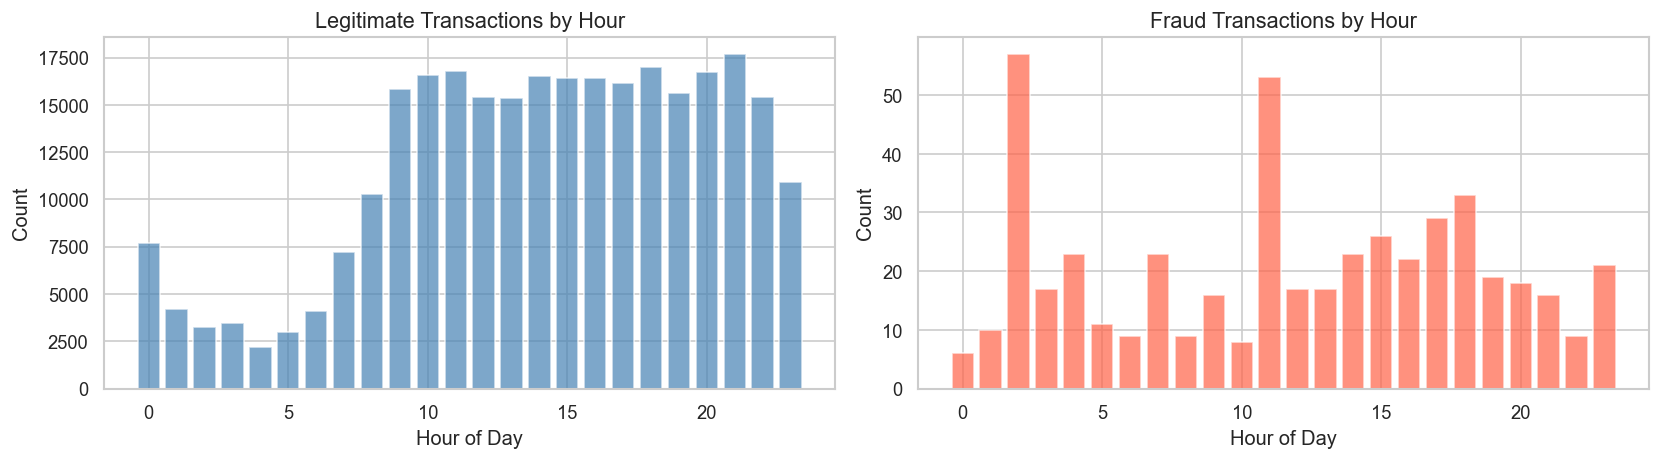

⚠️  Takeaway: Fraud is more evenly distributed across hours.
   Legitimate transactions drop sharply at night — the hour feature captures this signal.


In [16]:
df['hour'] = (df['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Transactions per hour
hourly_legit = df[df['Class'] == 0].groupby('hour').size()
hourly_fraud = df[df['Class'] == 1].groupby('hour').size()

axes[0].bar(hourly_legit.index, hourly_legit.values, alpha=0.7,
            color='steelblue', label='Legitimate')
axes[0].set_title('Legitimate Transactions by Hour', fontsize=13)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')

axes[1].bar(hourly_fraud.index, hourly_fraud.values, alpha=0.7,
            color='tomato', label='Fraud')
axes[1].set_title('Fraud Transactions by Hour', fontsize=13)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('⚠️  Takeaway: Fraud is more evenly distributed across hours.')
print('   Legitimate transactions drop sharply at night — the hour feature captures this signal.')

## 5. PCA Feature Distributions — Fraud vs. Legitimate

Comparing the distribution of each V-feature between classes reveals which features carry the most discriminative signal.

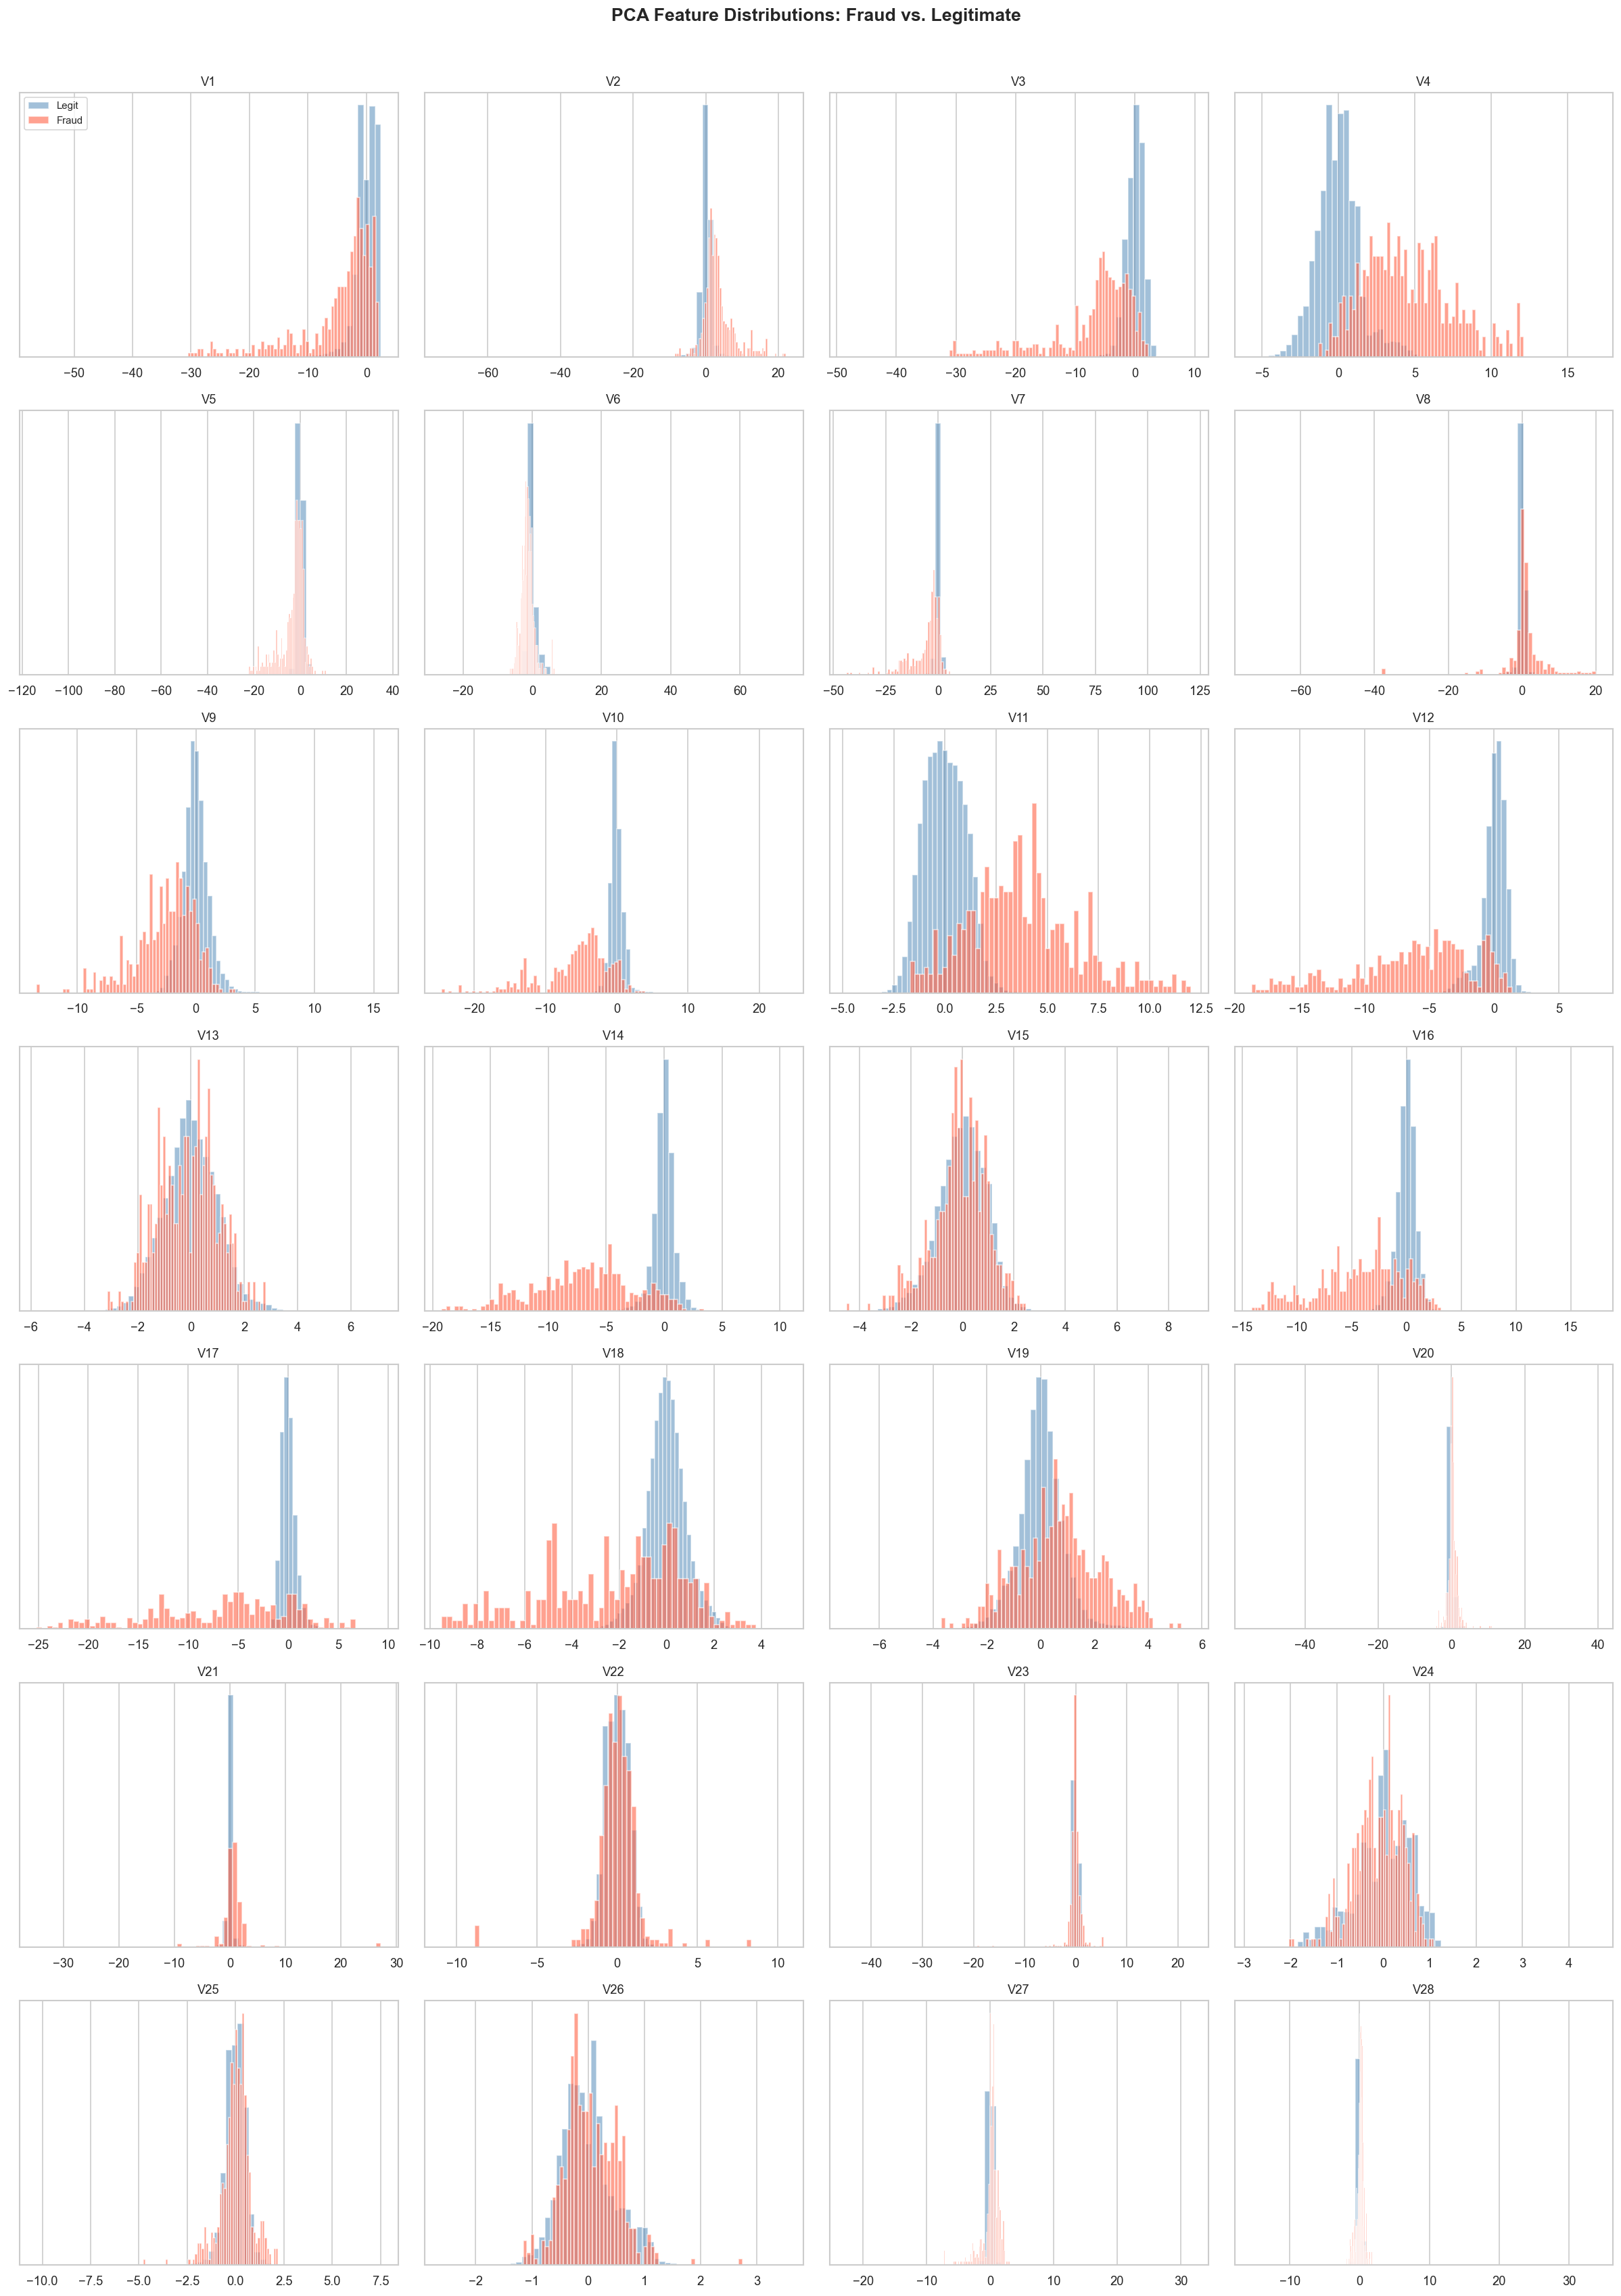

⚠️  Takeaway: V4, V11, V12, V14, V17 show the clearest separation between classes.
   These will likely rank highest in SHAP feature importance.


In [17]:
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(v_features):
    axes[i].hist(legit[col], bins=60, alpha=0.5, color='steelblue',
                 label='Legit', density=True)
    axes[i].hist(fraud[col], bins=60, alpha=0.6, color='tomato',
                 label='Fraud', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('PCA Feature Distributions: Fraud vs. Legitimate',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('⚠️  Takeaway: V4, V11, V12, V14, V17 show the clearest separation between classes.')
print('   These will likely rank highest in SHAP feature importance.')

## 6. Correlation Heatmap

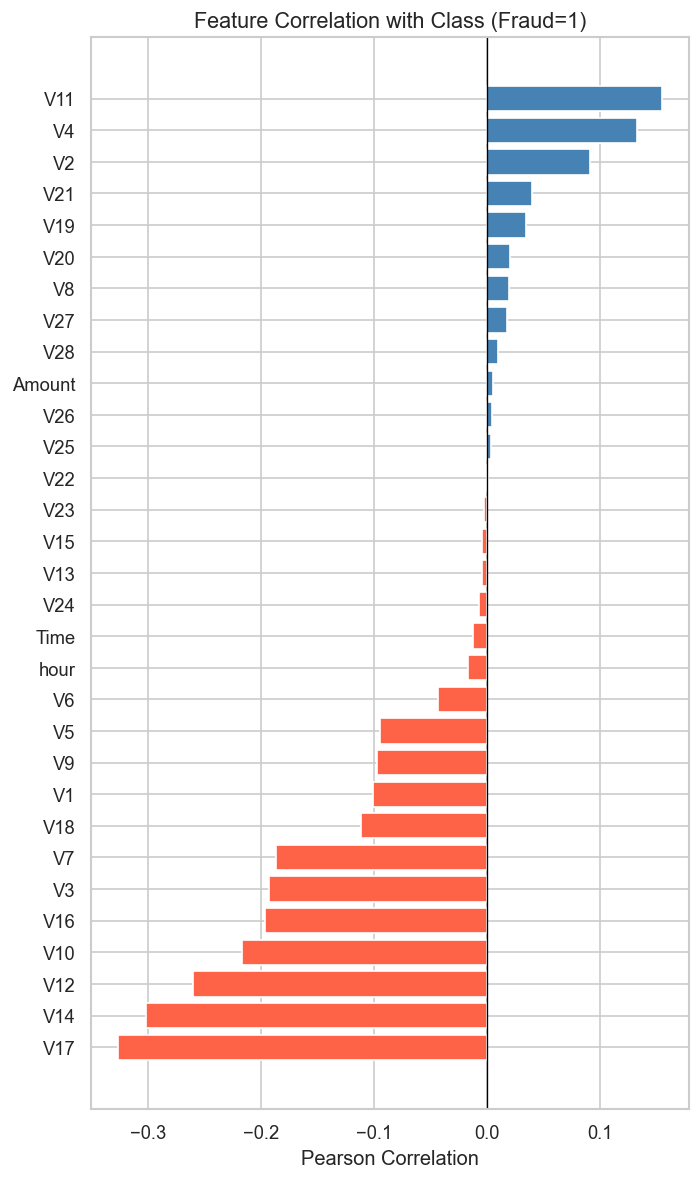

Top positive correlations (associated with fraud):
V19    0.0348
V21    0.0404
V2     0.0913
V4     0.1334
V11    0.1549
Name: Class, dtype: float64

Top negative correlations (associated with legitimate):
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
Name: Class, dtype: float64


In [18]:
# Correlation with the target
corr_with_target = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(6, 10))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Class (Fraud=1)', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Top positive correlations (associated with fraud):')
print(corr_with_target.tail(5).round(4))
print()
print('Top negative correlations (associated with legitimate):')
print(corr_with_target.head(5).round(4))

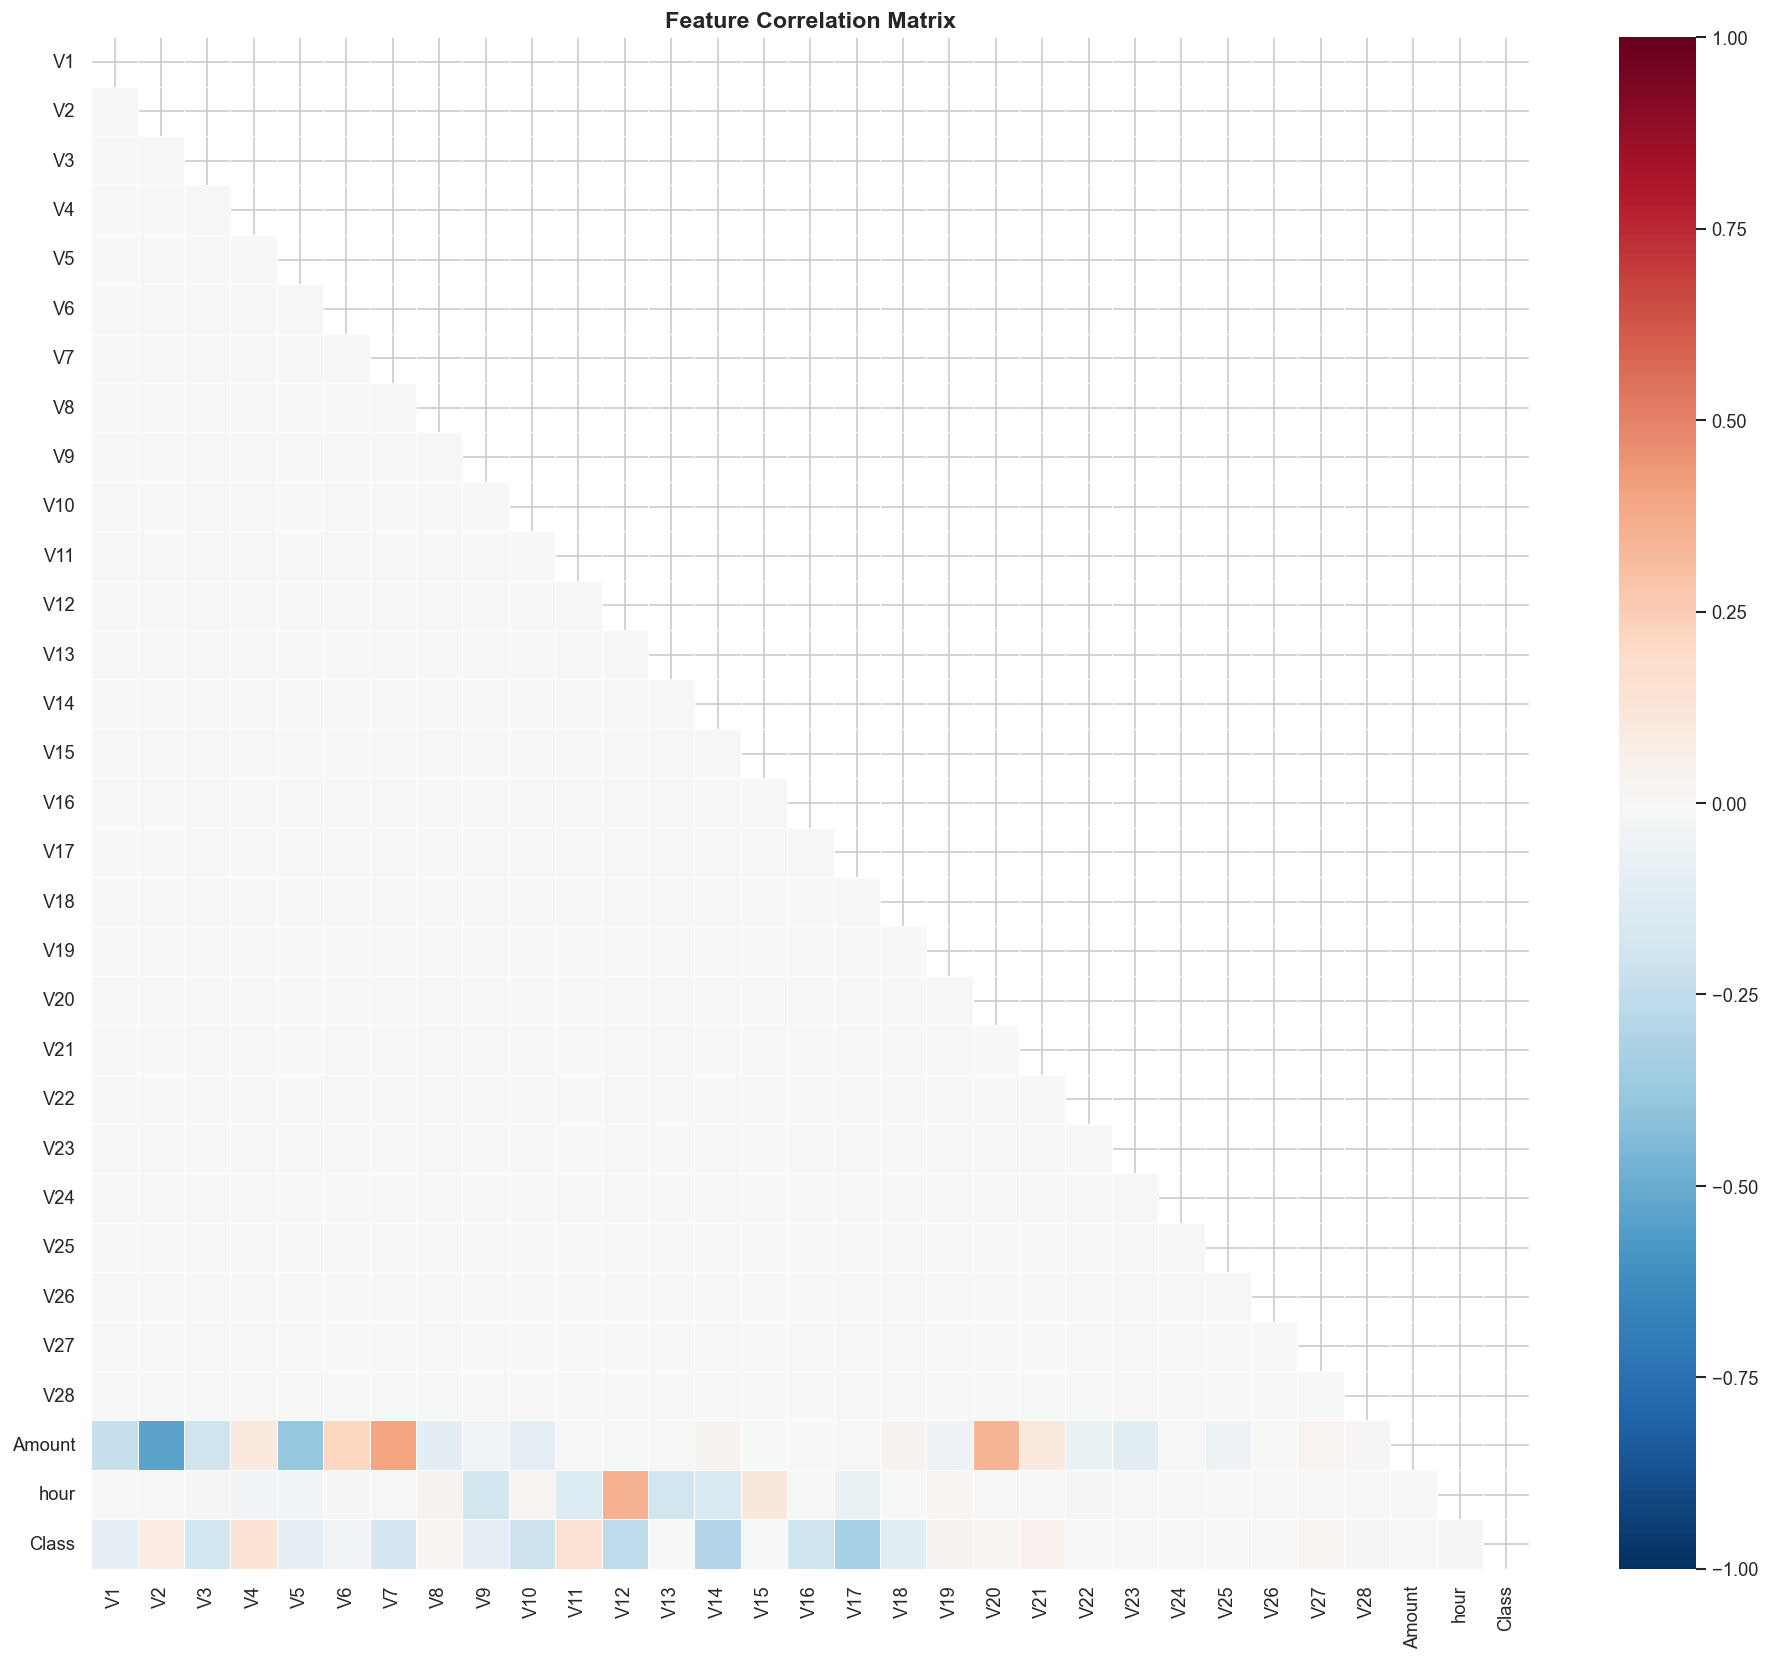

⚠️  Takeaway: PCA features are largely uncorrelated with each other (by design).
   No multicollinearity issues to worry about.


In [19]:
# Full correlation matrix for V-features only
fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = df[v_features + ['Amount', 'hour', 'Class']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('⚠️  Takeaway: PCA features are largely uncorrelated with each other (by design).')
print('   No multicollinearity issues to worry about.')

## 7. Boxplots — Top Discriminative Features

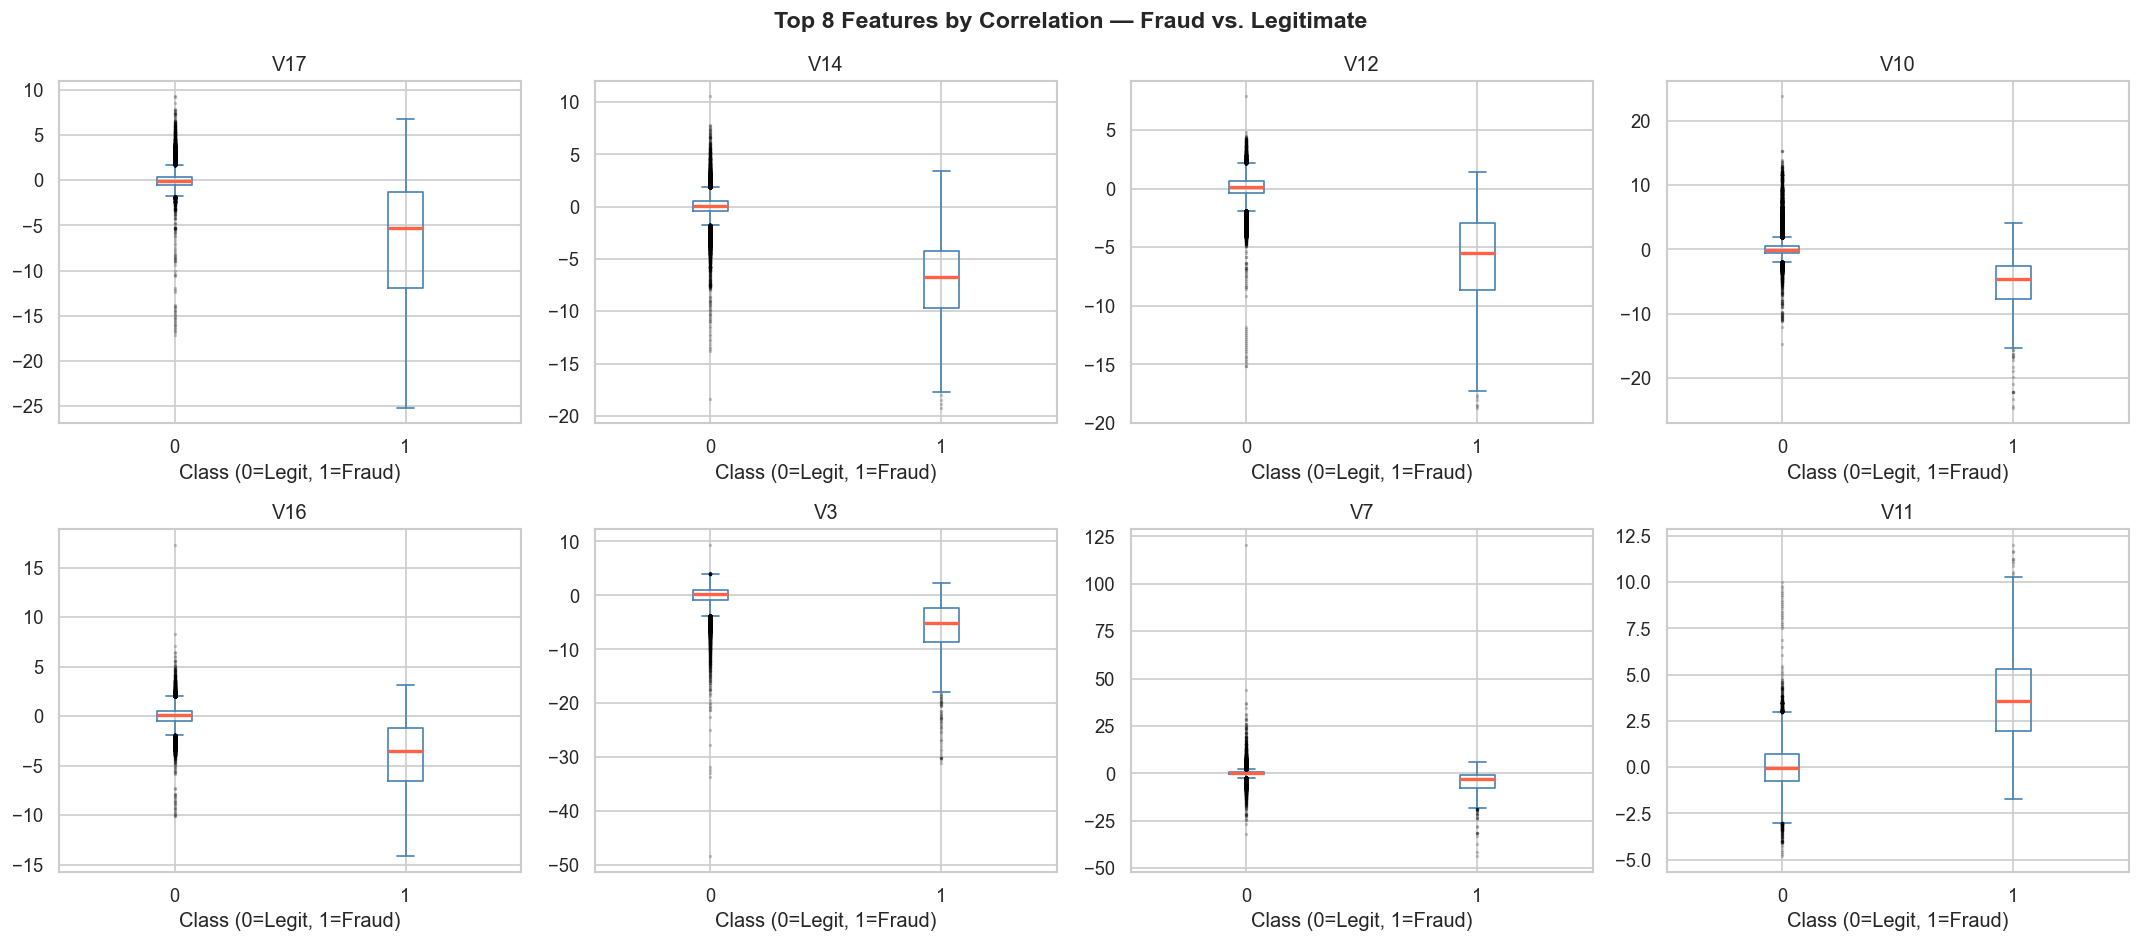

In [20]:
# Pick the 8 features with highest absolute correlation to Class
top_features = corr_with_target.abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    df.boxplot(column=col, by='Class', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'),
               flierprops=dict(marker='.', alpha=0.2, markersize=2))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Class (0=Legit, 1=Fraud)')

plt.suptitle('Top 8 Features by Correlation — Fraud vs. Legitimate',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Key Takeaways for Modelling

| Observation | Modelling Decision |
|---|---|
| ~0.17% fraud rate (577:1 imbalance) | Use `scale_pos_weight` in XGBoost; evaluate with PR-AUC and F1, not accuracy |
| Fraud amounts tend to be smaller | `Amount` is a useful feature; StandardScaler applied |
| Fraud is spread across all hours | `hour` feature adds signal for legitimate transaction patterns |
| V4, V11, V12, V14, V17 show clear class separation | Expect these to dominate SHAP importance |
| PCA features are uncorrelated | No need for further dimensionality reduction |
| No missing values | No imputation needed |

**Threshold note:** The default 0.5 threshold is not optimal for imbalanced fraud detection.  
The API uses a threshold of `0.7` to reduce false positives in production.